In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, r2_score,
    roc_auc_score, roc_curve, root_mean_squared_error,
    precision_recall_curve, average_precision_score, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Load data
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print('Train shape:', train_df.shape)
print('Test  shape:', test_df.shape)
print()

# Feature Engineering 
def engineer_features(df, user_fraud_map=None, device_fraud_map=None,
                       user_count_map=None, global_fr=None):
    df = df.copy()
    df['hour']        = (df['timestamp'] // 3600) % 24
    df['day_of_week'] = (df['timestamp'] // 86400) % 7
    df['log_amount']  = np.log1p(df['amount'])
    if user_fraud_map is None:
        # Training: compute from self
        global_fr             = df['label'].mean()
        user_fraud_map        = df.groupby('user_id')['label'].mean()
        device_fraud_map      = df.groupby('device_id')['label'].mean()
        user_count_map        = df.groupby('user_id')['label'].count()
    df['user_fraud_rate']   = df['user_id'].map(user_fraud_map).fillna(global_fr)
    df['device_fraud_rate'] = df['device_id'].map(device_fraud_map).fillna(global_fr)
    df['user_txn_count']    = df['user_id'].map(user_count_map).fillna(1)
    return df, user_fraud_map, device_fraud_map, user_count_map, global_fr

train_df, ufm, dfm, ucm, gfr = engineer_features(train_df)

FEATURE_COLS = ['amount', 'merchant_category', 'country', 'channel',
                'hours_since_prev_txn', 'hour', 'day_of_week',
                'log_amount', 'user_fraud_rate', 'device_fraud_rate',
                'user_txn_count']

X = train_df[FEATURE_COLS].values
y = train_df['label'].values

# Split / Train
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain : {X_train.shape[0]} rows | Fraud: {y_train.mean()*100:.2f}%')
print(f'Val   : {X_val.shape[0]} rows | Fraud: {y_val.mean()*100:.2f}%')

# Scale
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_v_sc  = scaler.transform(X_val)

def print_metrics(y_true, y_pred, y_prob, name):
    
    print(f'  {name} — Evaluation Metrics')
    
    print(f'  Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  Recall    : {recall_score(y_true, y_pred):.4f}')
    print(f'  F1-Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}')

    
    print(classification_report(y_true, y_pred,
          target_names=['Legit','Fraud'], zero_division=0))

print('\n✅ Preprocessing complete — ready to train.')

Train shape: (182125, 10)
Test  shape: (45531, 9)


Train : 145700 rows | Fraud: 1.64%
Val   : 36425 rows | Fraud: 1.64%

✅ Preprocessing complete — ready to train.


Training completed.


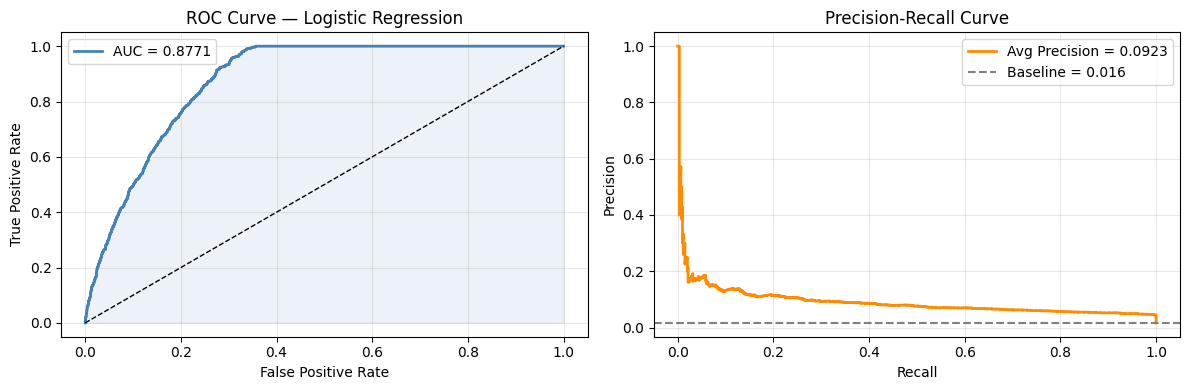


Confusion Matrix:
 [[29138  6689]
 [  161   437]]
  MAE       : 0.19
  MSE       : 0.19
  RMSE      : 0.43
  R2 score  : -10.65

  Logistic Regression — Evaluation Metrics
  Accuracy  : 0.8119
  Precision : 0.0613
  Recall    : 0.7308
  F1-Score  : 0.1132
              precision    recall  f1-score   support

       Legit       0.99      0.81      0.89     35827
       Fraud       0.06      0.73      0.11       598

    accuracy                           0.81     36425
   macro avg       0.53      0.77      0.50     36425
weighted avg       0.98      0.81      0.88     36425



In [7]:

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    C=0.5,
    solver='lbfgs',
    random_state=42
)
lr_model.fit(X_tr_sc, y_train)
print('Training completed.')

lr_pred = lr_model.predict(X_v_sc)
lr_prob = lr_model.predict_proba(X_v_sc)[:, 1]

# Graphs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_val, lr_prob)
auc_lr = roc_auc_score(y_val, lr_prob)
axes[0].plot(fpr_lr, tpr_lr, color='steelblue', lw=2, label=f'AUC = {auc_lr:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].fill_between(fpr_lr, tpr_lr, alpha=0.1, color='steelblue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Logistic Regression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
prec_lr, rec_lr, _ = precision_recall_curve(y_val, lr_prob)
ap_lr = average_precision_score(y_val, lr_prob)
axes[1].plot(rec_lr, prec_lr, color='darkorange', lw=2, label=f'Avg Precision = {ap_lr:.4f}')
axes[1].axhline(y=y_val.mean(), color='gray', linestyle='--', label=f'Baseline = {y_val.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Metrics

print("\nConfusion Matrix:\n",confusion_matrix(y_val, lr_pred))
print(f"  MAE       : {mean_absolute_error(y_val, lr_pred):.2f}")
print(f"  MSE       : {mean_squared_error(y_val, lr_pred):.2f}")
print(f"  RMSE      : {root_mean_squared_error(y_val, lr_pred):.2f}")
print(f"  R2 score  : {r2_score(y_val, lr_pred):.2f}")
print()

print_metrics(y_val, lr_pred, lr_prob, 'Logistic Regression')

Training completed.


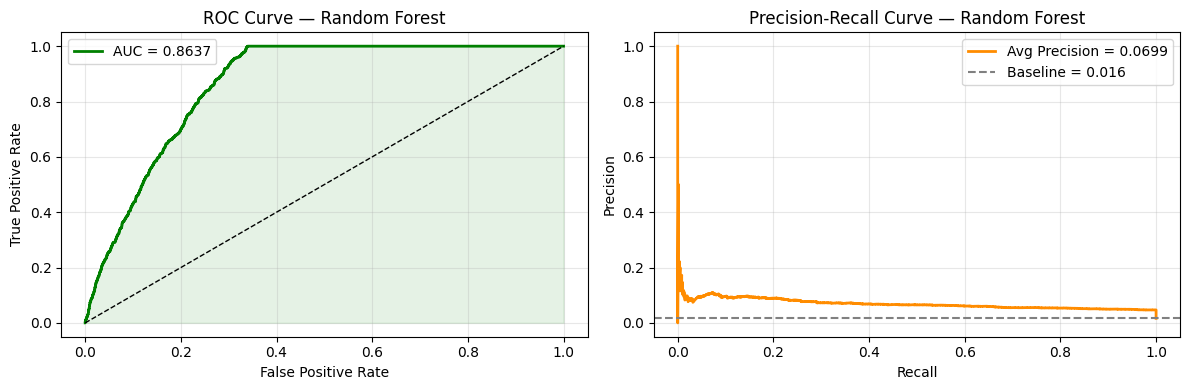


Confusion Matrix:
 [[24410 11417]
 [   24   574]]

  Random Forest — Evaluation Metrics
  Accuracy  : 0.6859
  Precision : 0.0479
  Recall    : 0.9599
  F1-Score  : 0.0912
              precision    recall  f1-score   support

       Legit       1.00      0.68      0.81     35827
       Fraud       0.05      0.96      0.09       598

    accuracy                           0.69     36425
   macro avg       0.52      0.82      0.45     36425
weighted avg       0.98      0.69      0.80     36425



In [3]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)   # RF does not need scaling
print('Training completed.')

rf_pred = rf_model.predict(X_val)
rf_prob = rf_model.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_val, rf_prob)
auc_rf = roc_auc_score(y_val, rf_prob)
axes[0].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'AUC = {auc_rf:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].fill_between(fpr_rf, tpr_rf, alpha=0.1, color='green')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Random Forest')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
prec_rf, rec_rf, _ = precision_recall_curve(y_val, rf_prob)
ap_rf = average_precision_score(y_val, rf_prob)
axes[1].plot(rec_rf, prec_rf, color='darkorange', lw=2, label=f'Avg Precision = {ap_rf:.4f}')
axes[1].axhline(y=y_val.mean(), color='gray', linestyle='--', label=f'Baseline = {y_val.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Random Forest')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nConfusion Matrix:\n",confusion_matrix(y_val, rf_pred))
print()
print_metrics(y_val, rf_pred, rf_prob, 'Random Forest')

Training completed.


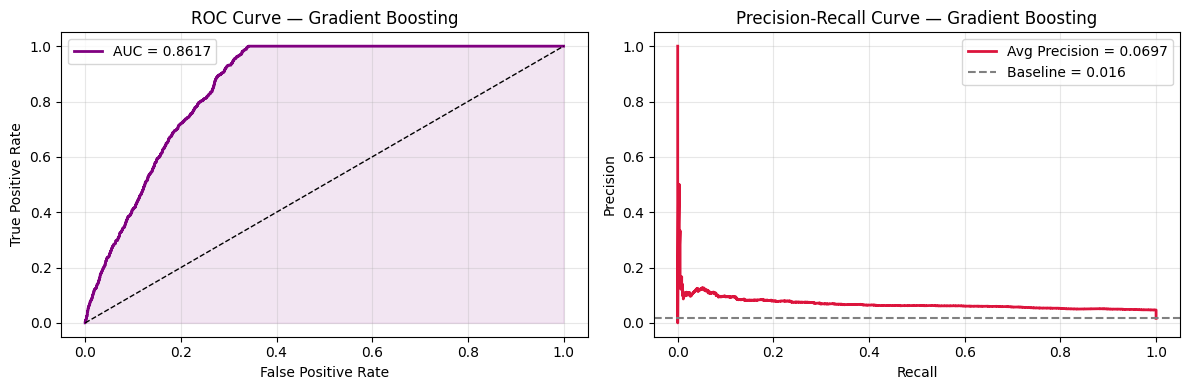


Confusion Matrix:
 [[35818     9]
 [  595     3]]

  Gradient Boosting — Evaluation Metrics
  Accuracy  : 0.9834
  Precision : 0.2500
  Recall    : 0.0050
  F1-Score  : 0.0098
              precision    recall  f1-score   support

       Legit       0.98      1.00      0.99     35827
       Fraud       0.25      0.01      0.01       598

    accuracy                           0.98     36425
   macro avg       0.62      0.50      0.50     36425
weighted avg       0.97      0.98      0.98     36425



In [4]:

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    min_samples_leaf=10,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
print('Training completed.')

gb_pred = gb_model.predict(X_val)
gb_prob = gb_model.predict_proba(X_val)[:, 1]

# Graphs 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
fpr_gb, tpr_gb, _ = roc_curve(y_val, gb_prob)
auc_gb = roc_auc_score(y_val, gb_prob)
axes[0].plot(fpr_gb, tpr_gb, color='purple', lw=2, label=f'AUC = {auc_gb:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].fill_between(fpr_gb, tpr_gb, alpha=0.1, color='purple')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Gradient Boosting')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
prec_gb, rec_gb, _ = precision_recall_curve(y_val, gb_prob)
ap_gb = average_precision_score(y_val, gb_prob)
axes[1].plot(rec_gb, prec_gb, color='crimson', lw=2, label=f'Avg Precision = {ap_gb:.4f}')
axes[1].axhline(y=y_val.mean(), color='gray', linestyle='--', label=f'Baseline = {y_val.mean():.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Gradient Boosting')
axes[1].legend(); axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# Metrics

print("\nConfusion Matrix:\n",confusion_matrix(y_val, gb_pred))
print()
print_metrics(y_val, gb_pred, gb_prob, 'Gradient Boosting')
